In [1]:
import sys, os
if os.path.basename(os.getcwd()) == 'notebooks':
    sys.path.insert(0, '..')

# 05 — Regularization Study
Compare L1, L2, and Elastic Net across C values and datasets. Analyze sparsity and cross-dataset stability.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold
from src.data_loader import get_all_datasets
from src.preprocessing import get_pipelines
from src.models import make_regularized, C_VALUES, L1_RATIOS
from src.evaluation import (
    cross_val_evaluate, summarize_cv_results, count_nonzero_coefs,
    plot_regularization_curve, save_table
)
from src.comparative_analysis import build_regularization_table
from src.utils import RANDOM_STATE

datasets = get_all_datasets()
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

holdout = {}
for name, (X, y) in datasets.items():
    X_main, X_test, y_main, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)
    holdout[name] = (X_main, y_main, X_test, y_test)

2026-05-15 19:53:54,222 — Loading Bonn EEG (extracted 6-dim features)...


In [3]:
# Run regularization sweep
reg_results = {}
sparsity_rows = []
for dataset_name, (X, y, _, _) in holdout.items():
    pipelines = get_pipelines(dataset_name)
    for pipe_name, pipe in pipelines.items():
        for reg_type in ['L1', 'L2', 'ElasticNet']:
            for C in C_VALUES:
                if reg_type == 'ElasticNet':
                    for l1r in L1_RATIOS:
                        model = make_regularized(reg_type, C, l1r)
                        results = cross_val_evaluate(pipe, model, X, y, CV)
                        reg_results[(f'{reg_type}(l1={l1r})', C, dataset_name, pipe_name)] = results
                else:
                    model = make_regularized(reg_type, C)
                    results = cross_val_evaluate(pipe, model, X, y, CV)
                    reg_results[(reg_type, C, dataset_name, pipe_name)] = results

                    # Sparsity on last fold
                    from sklearn.model_selection import StratifiedKFold as SKF
                    cv_tmp = SKF(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
                    train_idx, _ = list(cv_tmp.split(X, y))[-1]
                    X_t = pipe.fit_transform(X[train_idx], y[train_idx])
                    m = make_regularized(reg_type, C)
                    m.fit(X_t, y[train_idx])
                    sparsity_rows.append({
                        'reg_type': reg_type, 'C': C,
                        'dataset': dataset_name, 'pipeline': pipe_name,
                        'nonzero_coefs': count_nonzero_coefs(m),
                        'feature_count_after_preprocessing': X_t.shape[1],
                    })
print(f'Total reg_results entries: {len(reg_results)}')

c:\Users\deepthink\AppData\Local\Programs\Python\Python311\Lib\site-packages\pywt\_multilevel.py:43: UserWarning: Level value of 4 is too high: all coefficients will experience boundary effects.
  warnings.warn(
c:\Users\deepthink\AppData\Local\Programs\Python\Python311\Lib\site-packages\pywt\_multilevel.py:43: UserWarning: Level value of 4 is too high: all coefficients will experience boundary effects.
  warnings.warn(
c:\Users\deepthink\AppData\Local\Programs\Python\Python311\Lib\site-packages\pywt\_multilevel.py:43: UserWarning: Level value of 4 is too high: all coefficients will experience boundary effects.
  warnings.warn(
c:\Users\deepthink\AppData\Local\Programs\Python\Python311\Lib\site-packages\pywt\_multilevel.py:43: UserWarning: Level value of 4 is too high: all coefficients will experience boundary effects.
  warnings.warn(
c:\Users\deepthink\AppData\Local\Programs\Python\Python311\Lib\site-packages\pywt\_multilevel.py:43: UserWarning: Level value of 4 is too high: all coef

Total reg_results entries: 140


In [4]:
# Table 3: Regularization results
table3 = build_regularization_table(reg_results)
save_table(table3, 'table3_regularization')

# Show best C per reg type per dataset (Pipeline A)
for ds in holdout.keys():
    print(f'\n=== {ds} — Pipeline A ===')
    subset = table3[(table3['Dataset'] == ds) & (table3['Pipeline'] == 'A')]
    best = subset.loc[subset.groupby('Regularization')['pr_auc_mean'].idxmax()]
    print(best[['Regularization', 'C', 'pr_auc_mean', 'pr_auc_std']].to_string(index=False))


=== uci_seizure — Pipeline A ===
    Regularization    C  pr_auc_mean  pr_auc_std
ElasticNet(l1=0.3) 0.01     0.483438    0.015322
ElasticNet(l1=0.5) 0.10     0.499387    0.018740
ElasticNet(l1=0.7) 0.10     0.490152    0.019739
                L1 0.01     0.480800    0.022171
                L2 0.10     0.494955    0.017955

=== bonn_eeg — Pipeline A ===
    Regularization    C  pr_auc_mean  pr_auc_std
ElasticNet(l1=0.3) 10.0     0.881695    0.026692
ElasticNet(l1=0.5) 10.0     0.882150    0.027421
ElasticNet(l1=0.7)  1.0     0.882286    0.027493
                L1  1.0     0.883537    0.026847
                L2 10.0     0.881864    0.027224

=== eeg_eye_state — Pipeline A ===
    Regularization    C  pr_auc_mean  pr_auc_std
ElasticNet(l1=0.3) 10.0     0.604408    0.013865
ElasticNet(l1=0.5) 10.0     0.604387    0.013864
ElasticNet(l1=0.7) 10.0     0.604386    0.013863
                L1 10.0     0.604381    0.013866
                L2 10.0     0.610457    0.010317


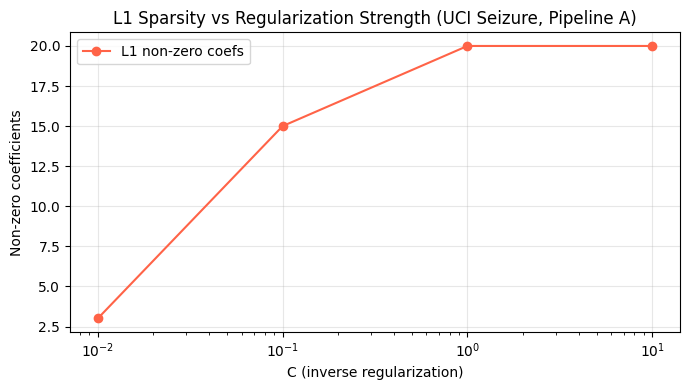

In [5]:
# Table 2: Sparsity
table2 = pd.DataFrame(sparsity_rows)
save_table(table2, 'table2_sparsity')

# Sparsity: non-zero coefs vs C for L1 on UCI Seizure Pipeline A
subset = table2[(table2['dataset'] == 'uci_seizure') & 
                (table2['pipeline'] == 'A') & 
                (table2['reg_type'] == 'L1')].sort_values('C')

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(subset['C'], subset['nonzero_coefs'], marker='o', color='tomato', label='L1 non-zero coefs')
ax.set_xscale('log')
ax.set_xlabel('C (inverse regularization)')
ax.set_ylabel('Non-zero coefficients')
ax.set_title('L1 Sparsity vs Regularization Strength (UCI Seizure, Pipeline A)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../results/figures/l1_sparsity.png', dpi=150)
plt.show()

In [6]:
# Regularization curve: L1 vs L2 on UCI Seizure Pipeline A
curve_data = []
for reg_type in ['L1', 'L2']:
    for C in C_VALUES:
        r = reg_results.get((reg_type, C, 'uci_seizure', 'A'))
        if r:
            curve_data.append({'reg_type': reg_type, 'C': C,
                               'mean': r['pr_auc'].mean(), 'std': r['pr_auc'].std()})

plot_regularization_curve(
    pd.DataFrame(curve_data), 'PR-AUC',
    title='Regularization Strength vs PR-AUC (UCI Seizure, Pipeline A)',
    save_path='../results/figures/reg_curve_uci.png'
)
print('Regularization curve saved.')

Regularization curve saved.


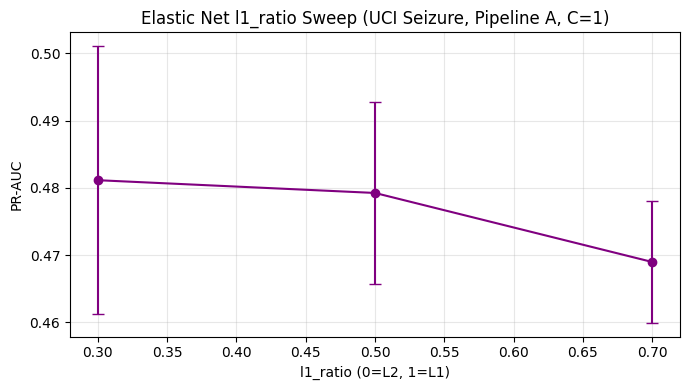

In [7]:
# Elastic Net l1_ratio sweep on UCI Seizure Pipeline A at C=1
en_data = []
for l1r in L1_RATIOS:
    key = (f'ElasticNet(l1={l1r})', 1.0, 'uci_seizure', 'A')
    if key in reg_results:
        r = reg_results[key]
        en_data.append({'l1_ratio': l1r, 'mean': r['pr_auc'].mean(), 'std': r['pr_auc'].std()})

if en_data:
    en_df = pd.DataFrame(en_data)
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.errorbar(en_df['l1_ratio'], en_df['mean'], yerr=en_df['std'], marker='o', capsize=4, color='purple')
    ax.set_xlabel('l1_ratio (0=L2, 1=L1)')
    ax.set_ylabel('PR-AUC')
    ax.set_title('Elastic Net l1_ratio Sweep (UCI Seizure, Pipeline A, C=1)')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('../results/figures/elasticnet_l1ratio.png', dpi=150)
    plt.show()

In [8]:
# Cross-dataset stability: std of best PR-AUC across datasets per reg type
stability = []
for reg_type in ['L1', 'L2']:
    best_per_ds = []
    for ds in holdout.keys():
        best = max(
            [reg_results[(reg_type, C, ds, 'A')]['pr_auc'].mean()
             for C in C_VALUES if (reg_type, C, ds, 'A') in reg_results],
            default=np.nan
        )
        best_per_ds.append(best)
    stability.append({'Regularization': reg_type,
                      'Mean PR-AUC across datasets': np.nanmean(best_per_ds),
                      'Std (stability)': np.nanstd(best_per_ds)})

pd.DataFrame(stability)

,Regularization,Mean PR-AUC across datasets,Std (stability)
0,L1,0.656240,0.168456
1,L2,0.662425,0.162173
